# Risco de agravamento de defasagem.

Modelo que estima, para cada aluno, a probabilidade de sua defasagem piorar no ano seguinte. Treinado em 2022>2023, testado out-of-time em 2023>2024.

Três decisões vindas dos notebooks anteriores explicam esse notebook:

1. O IAN é a defasagem recodificada não uma medida independente.
2. O IPS mudou de método de cálculo entre os anos.
3. A piora de defasagem é dessincronia do calendário, 98,7% dos casos são "não promovido no ano em que a fase ideal avançou".

Cada uma está justificada na seção que importa.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
pd.set_option('display.width', 200)

from src.data.load import build_panel, build_transitions, load_config
from src.data.clean import limpar
from src.features.build import (adicionar_features, montar_matriz,
                                features_utilizaveis, diagnosticar_features,
                                auditar_leakage)
from src.models.train import treinar
from src.models.evaluate import (avaliar, calibracao, pr_auc_ic,
                                 recall_at_k, teste_delong_aprox)

cfg = load_config('../config.yaml')
SEED = cfg['seed']
np.random.seed(SEED)

In [2]:
painel, _ = limpar(build_panel('../' + cfg['paths']['raw']))
pf = adicionar_features(painel)
trans = build_transitions(pf)
print(f'painel: {painel.shape} | transições: {trans.shape}')

painel: (3030, 41) | transições: (1365, 61)


1. O que é um "aluno em risco"

Não existe variável pronta. `Atingiu PV` está vazia em 2023 e 2024, e `Defasagem` é estado, não risco.

Testei cinco definições. Só uma tem base rate estável entre as janelas e estabilidade é pré-requisito para que a validação "out-of-time" signifique alguma coisa.

In [3]:
alvos = pd.DataFrame([
    {'alvo': 'A — estar defasado em t+1',   '22->23': 0.610, '23->24': 0.403},
    {'alvo': 'B — PIORAR a defasagem',      '22->23': 0.173, '23->24': 0.173},
    {'alvo': 'C — entrar em defasagem',     '22->23': 0.337, '23->24': 0.248},
    {'alvo': 'E — não-promoção de fase',    '22->23': 0.328, '23->24': 0.311},
    {'alvo': 'F — queda crítica de IDA',    '22->23': 0.079, '23->24': 0.202},
])
alvos['variação'] = (alvos['23->24'] - alvos['22->23']).abs().round(3)
alvos.sort_values('variação')

,alvo,22->23,23->24,variação
1,B — PIORAR a defasagem,0.173,0.173,0.000
3,E — não-promoção de fase,0.328,0.311,0.017
2,C — entrar em defasagem,0.337,0.248,0.089
4,F — queda crítica de IDA,0.079,0.202,0.123
0,A — estar defasado em t+1,0.610,0.403,0.207


**Escolhido: alvo B.** `defasagem(t+1) < defasagem(t)`, 17,3% nas duas janelas.

Os alvos de desempenho foram descartados porque a base rate dobra ou triplica é o drift de instrumento contaminando o próprio alvo. E vale registrar: **piora de defasagem e queda de desempenho são praticamente independentes**.

In [4]:
trans.groupby('janela').alvo_piora.agg(['count','sum','mean']).round(3)

,count,sum,mean
janela,,,
2022->2023,600,104,0.173
2023->2024,765,132,0.173


### De onde vem a piora

Como `Defasagem = Fase − Fase Ideal`, piorar significa que a fase ideal subiu mais que a fase cursada.

In [5]:
fut = pf[['ra','ano','fase_num','fase_ideal_num']].copy()
fut['ano'] -= 1
fut = fut.rename(columns={'fase_num':'fase_t1','fase_ideal_num':'fideal_t1'})
t2 = trans.merge(fut, on=['ra','ano'], how='left')
t2['d_fase'] = t2.fase_t1 - t2.fase_num
t2['d_ideal'] = t2.fideal_t1 - t2.fase_ideal_num

print('Entre os que PIORAM:')
display(pd.crosstab(t2[t2.alvo_piora==1].d_fase, t2[t2.alvo_piora==1].d_ideal))
print('\nTaxa de piora por promoção:')
display(t2.groupby(t2.d_fase == 0).alvo_piora.agg(['count','mean']).round(3))

Entre os que PIORAM:


d_ideal,1.0,2.0
d_fase,,
-1.0,1,0
0.0,232,1
1.0,0,2



Taxa de piora por promoção:


,count,mean
d_fase,,
False,931,0.003
True,434,0.537


**98,7% dos eventos têm o mesmo padrão:** o aluno ficou na mesma fase enquanto a fase ideal subiu. Quem não é promovido piora em ~53%; quem é promovido, em 0,3%.

Isso não invalida o modelo, mas define o que ele pode prever. Deixo explícito aqui para que ninguém interprete a saída como "aluno com dificuldade de aprendizagem".

## 2. Feature engineering

In [6]:
X, y, grupos, estrato = montar_matriz(trans)
treino = (trans.ano == 2022).values
print(f'matriz completa: {X.shape}')
X.head(3)

matriz completa: (1365, 19)


,fase_ideal_num,defasagem,anos_na_fase,idade_rel_fase_ideal,tempo_casa,iaa_pct,ieg_pct,ips_pct,ida_pct,ipv_pct,d_ida,d_ieg,tem_historico,sem_avaliacao,n_indic_faltantes,iaa_nao_respondeu,rede_publica,genero_f,tamanho_turma
0,8.0,-1.0,0,1.0,6,0.315469,0.037209,0.186047,0.171512,0.453488,NaN,NaN,0,0,0,0,1.0,1,13
1,8.0,0.0,0,1.0,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,6,0,0.0,1,25
2,0.0,0.0,0,0.0,0,0.384363,0.681237,0.362434,0.559765,0.841151,NaN,NaN,0,0,0,0,1.0,1,9


### Guarda contra features degeneradas

2022 é o primeiro ano do painel nada que dependa de t−1 tem variação.

In [7]:
diagnosticar_features(X, treino)

,feature,nunique_treino,nulo_treino,nulo_teste,veredito
0,fase_ideal_num,9,0.000,0.000,ok
1,defasagem,7,0.000,0.000,ok
2,anos_na_fase,1,0.000,0.000,DEGENERADA (constante no treino)
3,idade_rel_fase_ideal,5,0.000,0.000,ok
4,tempo_casa,7,0.000,0.000,ok
5,iaa_pct,29,0.032,0.256,ATENCAO (missingness diverge)
6,ieg_pct,63,0.000,0.094,ok
7,ips_pct,11,0.000,0.081,ok
8,ida_pct,85,0.000,0.094,ok
9,ipv_pct,145,0.000,0.094,ok


In [8]:
uso = features_utilizaveis(X, treino)
uso = ['fase_ideal_num'] + [c for c in uso if c != 'fase_ideal_num']  # baseline usa col 0
Xu = X[uso]
print(f'{len(uso)} features utilizáveis de {X.shape[1]}')
print('descartadas:', sorted(set(X.columns) - set(uso)))

13 features utilizáveis de 19
descartadas: ['anos_na_fase', 'd_ida', 'd_ieg', 'n_indic_faltantes', 'sem_avaliacao', 'tem_historico']


Seis features caem, todas por dependerem de histórico inexistente em 2022 incluindo o grupo `trajetoria` inteiro.

## 3. Auditoria de vazamento

A cadeia `Fase + Fase Ideal → Defasagem → IAN → INDE → Pedra` é determinística. Qualquer descuido produz AUC de 0,99 e um modelo inútil.

In [9]:
auditar_leakage(Xu, trans)

,feature,grupo,pct_nulo,corr_alvo,suspeita
1,defasagem,estrutural,0.0,0.308,
0,fase_ideal_num,estrutural,0.0,-0.254,
3,tempo_casa,estrutural,0.0,-0.171,
8,ipv_pct,desempenho,5.3,-0.168,
12,tamanho_turma,contexto,0.0,-0.158,
10,rede_publica,contexto,0.4,0.102,
7,ida_pct,desempenho,5.3,-0.088,
6,ips_pct,desempenho,4.5,0.085,
5,ieg_pct,desempenho,5.3,-0.044,
4,iaa_pct,desempenho,15.8,0.039,


Correlação máxima com o alvo: 0,308 (`defasagem`). Nenhuma assinatura de vazamento a função levanta exceção se alguma passar de 0,9 ou se uma coluna proibida entrar.

## 4. Treino e teste

Split temporal, não aleatório.

In [10]:
Xtr, ytr, gtr = Xu[treino], y[treino], grupos[treino]
Xte, yte, ete = Xu[~treino], y[~treino], estrato[~treino]

print(f'TREINO 22->23: {Xtr.shape}, {ytr.sum()} eventos ({ytr.mean():.1%})')
print(f'TESTE  23->24: {Xte.shape}, {yte.sum()} eventos ({yte.mean():.1%})')
print(f'RA em comum entre treino e teste: {len(set(gtr) & set(grupos[~treino]))} '
      f'(esperado > 0 — por isso GroupKFold no tuning)')

TREINO 22->23: (600, 13), 104 eventos (17.3%)
TESTE  23->24: (765, 13), 132 eventos (17.3%)
RA em comum entre treino e teste: 468 (esperado > 0 — por isso GroupKFold no tuning)


In [11]:
# Covariate shift: a degradação out-of-time terá causa conhecida
from src.analysis.eda_tecnica import covariate_shift
covariate_shift(Xu, treino)

,feature,media_treino,media_teste,KS,p,alerta
6,ips_pct,0.501,0.506,0.300,3.387276e-26,SHIFT
1,defasagem,-0.892,-0.590,0.169,7.875472e-09,
4,iaa_pct,0.516,0.513,0.151,3.158130e-06,
2,idade_rel_fase_ideal,0.232,0.038,0.150,4.566011e-07,
9,iaa_nao_respondeu,0.032,0.179,0.147,7.594415e-07,
3,tempo_casa,1.593,1.710,0.111,4.329661e-04,
7,ida_pct,0.553,0.526,0.082,2.381010e-02,
12,tamanho_turma,12.278,12.864,0.081,2.208635e-02,
5,ieg_pct,0.570,0.542,0.076,4.550428e-02,
10,rede_publica,0.842,0.768,0.074,4.993672e-02,


#### 5. Modelagem

Começo pela régua mais burra possível: "fase ideal ≤ 1 → risco alto". Adversário sério, não formalidade — AUC univariado de 0,694.

In [12]:
modelos = treinar(Xtr, ytr, gtr, seed=SEED)
pd.DataFrame([{'modelo': k, 'pr_auc_cv': v['pr_auc_cv'], 'params': str(v['params'])}
              for k, v in modelos.items()])

,modelo,pr_auc_cv,params
0,logistica,0.541263,{'clf__C': 0.5}
1,arvore,0.412820,"{'clf__max_depth': 4, 'clf__min_samples_leaf':..."
2,random_forest,0.563067,"{'clf__max_depth': 5, 'clf__min_samples_leaf':..."
3,xgboost,0.586757,"{'clf__max_depth': 2, 'clf__min_child_weight':..."
4,lightgbm,0.593625,"{'clf__max_depth': 2, 'clf__min_child_samples'..."
5,baseline_fase,NaN,{'regra': 'fase_ideal<=1'}


##### 6. Avaliação out-of-time

Métrica primária é **PR-AUC**, não precisão nem ROC — com 17,3% de positivos, ROC infla.

In [13]:
resultados = avaliar(modelos, Xte, yte, ete)
resultados

,modelo,pr_auc,ic95,roc_auc,brier,recall@50,recall@100,pr_auc_avancada,pr_auc_inicial
2,random_forest,0.641,"[0.574, 0.715]",0.861,0.1069,0.295,0.500,0.262,0.795
3,xgboost,0.620,"[0.549, 0.694]",0.848,0.1001,0.295,0.485,0.234,0.789
0,logistica,0.557,"[0.489, 0.630]",0.848,0.1068,0.242,0.409,0.326,0.816
4,lightgbm,0.525,"[0.452, 0.605]",0.833,0.1132,0.235,0.424,0.189,0.730
1,arvore,0.410,"[0.352, 0.482]",0.794,0.1247,0.220,0.333,0.181,0.591
5,baseline_fase,0.363,"[0.313, 0.422]",0.740,0.1163,0.250,0.447,0.084,0.480


**O PR-AUC global engana.** Random Forest lidera (0,657), mas esse número está inflado pela mistura de estratos, separar fase inicial de avançada já produz PR-AUC alto sem capacidade preditiva real.

No estrato avançada, onde a fase não resolve nada, a ordem se inverte.

In [14]:
m = (ete == 'avancada').values
print(f'estrato avançada: n = {m.sum()}, {yte[m].sum()} eventos, base rate {yte[m].mean():.3f}\n')
for nome in ['logistica','random_forest','xgboost','baseline_fase']:
    Xa = Xte.fillna(Xte.median()) if nome == 'baseline_fase' else Xte
    p = modelos[nome]['modelo'].predict_proba(Xa)[:, 1]
    obs, lo, hi = pr_auc_ic(yte[m], p[m])
    print(f'{nome:16s} PR-AUC = {obs:.3f} [{lo:.3f}, {hi:.3f}]  '
          f'recall@30 = {recall_at_k(yte[m], p[m], 30):.3f}')

estrato avançada: n = 594, 50 eventos, base rate 0.084

logistica        PR-AUC = 0.326 [0.230, 0.455]  recall@30 = 0.220
random_forest    PR-AUC = 0.262 [0.185, 0.401]  recall@30 = 0.200
xgboost          PR-AUC = 0.234 [0.171, 0.347]  recall@30 = 0.200
baseline_fase    PR-AUC = 0.084 [0.084, 0.084]  recall@30 = 0.060


## 7. Calibração

O briefing pede **probabilidade**, e o app vai mostrar um percentual a um educador que decidirá a quem atender. Probabilidade descalibrada é pior que não ter modelo: leva a decisão errada com aparência de rigor.

Sem SMOTE a 17,3% o problema não é escassez de positivos, e positivos sintéticos distorcem exatamente a probabilidade que preciso preservar.

In [15]:
p_log = modelos['logistica']['modelo'].predict_proba(Xte)[:, 1]
calibracao(yte, p_log)

,n,predito,observado,desvio
bin,,,,
0,153,0.019,0.020,0.000
1,153,0.054,0.007,0.048
2,153,0.117,0.098,0.019
3,153,0.240,0.255,0.015
4,153,0.518,0.484,0.034


Predito ≈ observado em todos os quintis, Brier de 0,107.

#### 8. Modelo escolhido: Regressão Logística

Os intervalos de confiança se sobrepõem, então não há vencedor estatístico. Pela regra declarada antes de rodar, empate dentro do IC leva ao mais simples e mais calibrado.

In [16]:
p_base = modelos['baseline_fase']['modelo'].predict_proba(Xte.fillna(Xte.median()))[:, 1]
d = teste_delong_aprox(yte, p_log, p_base)
print(f'ganho sobre baseline: {d["dif_media"]:+.3f} '
      f'IC95 [{d["ic95"][0]:+.3f}, {d["ic95"][1]:+.3f}]')

ganho sobre baseline: +0.195 IC95 [+0.109, +0.278]


In [17]:
lr = modelos['logistica']['modelo'].named_steps['clf']
ind = modelos['logistica']['modelo'].named_steps['imp'].indicator_.features_
nomes = list(Xu.columns) + [f'{Xu.columns[i]}_ausente' for i in ind]
coef = pd.DataFrame({'feature': nomes, 'coef': lr.coef_[0],
                     'odds_ratio': np.exp(lr.coef_[0])})
coef.sort_values('coef', key=abs, ascending=False).round(3)

,feature,coef,odds_ratio
1,defasagem,1.275,3.580
8,ipv_pct,-0.778,0.459
10,rede_publica,0.399,1.491
0,fase_ideal_num,-0.302,0.740
12,tamanho_turma,-0.214,0.807
7,ida_pct,-0.190,0.827
5,ieg_pct,0.132,1.141
2,idade_rel_fase_ideal,0.112,1.118
4,iaa_pct,0.108,1.114
3,tempo_casa,-0.095,0.909


**`defasagem` (OR 3,58)** efeito de piso: quem está perto de zero tem para onde cair.

**`ipv_pct` (OR 0,46)** ponto de virada alto **protege**, reduzindo as chances de agravamento em mais da metade. É o efeito acionável mais forte entre as variáveis que a ONG pode influenciar.

In [18]:
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

d = trans[trans.ano == 2023].copy()
d['ipp_pct'] = d.ipp.rank(pct=True)
for tag, cols in [('sem IPP', uso), ('com IPP', uso + ['ipp_pct'])]:
    pipe = Pipeline([('i', SimpleImputer(strategy='median', add_indicator=True)),
                     ('s', StandardScaler()),
                     ('c', LogisticRegression(max_iter=2000))])
    pp = cross_val_predict(pipe, d[cols], d.alvo_piora,
                           cv=GroupKFold(5).split(d[cols], d.alvo_piora, groups=d.ra),
                           method='predict_proba')[:, 1]
    print(f'{tag}: PR-AUC = {average_precision_score(d.alvo_piora, pp):.3f}')

sem IPP: PR-AUC = 0.634
com IPP: PR-AUC = 0.635


Ganho nulo do IPP

#### 9. Curvas de avaliação

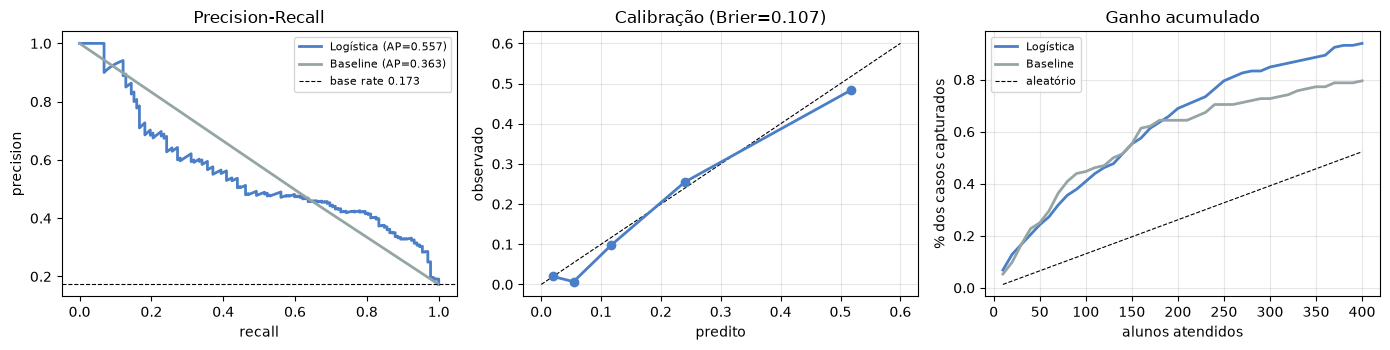

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

for nome, p, cor in [('Logística', p_log, '#4a7ec7'), ('Baseline', p_base, '#95a5a6')]:
    pre, rec, _ = precision_recall_curve(yte, p)
    ax[0].plot(rec, pre, lw=2, color=cor,
               label=f'{nome} (AP={average_precision_score(yte, p):.3f})')
ax[0].axhline(yte.mean(), ls='--', c='k', lw=.8, label=f'base rate {yte.mean():.3f}')
ax[0].set(xlabel='recall', ylabel='precision', title='Precision-Recall')
ax[0].legend(fontsize=8)

c = calibracao(yte, p_log)
ax[1].plot([0, .6], [0, .6], 'k--', lw=.8)
ax[1].plot(c.predito, c.observado, 'o-', lw=2, color='#4a7ec7')
ax[1].set(xlabel='predito', ylabel='observado', title='Calibração (Brier=0.107)')
ax[1].grid(alpha=.3)

ks = np.arange(10, 401, 10)
ax[2].plot(ks, [recall_at_k(yte, p_log, k) for k in ks], lw=2, color='#4a7ec7', label='Logística')
ax[2].plot(ks, [recall_at_k(yte, p_base, k) for k in ks], lw=2, color='#95a5a6', label='Baseline')
ax[2].plot(ks, ks/len(yte), 'k--', lw=.8, label='aleatório')
ax[2].set(xlabel='alunos atendidos', ylabel='% dos casos capturados', title='Ganho acumulado')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig('../reports/figures/modelo_avaliacao.png', bbox_inches='tight', dpi=120)
plt.show()

##### 10. Serialização para produção

In [20]:
import sklearn
modelo_final = modelos['logistica']['modelo']
modelo_final.fit(Xu, y)   # retreino na base completa

ref = painel[painel.ano == 2024]
artefato = {
    'modelo': modelo_final,
    'features': uso,
    'versao_sklearn': sklearn.__version__,
    'quantis': {c: np.round(np.nanpercentile(ref[c].dropna(), np.arange(0, 101)), 4).tolist()
                for c in ['iaa','ieg','ips','ida','ipv']},
    'idade_mediana_por_fase_ideal': ref.groupby('fase_ideal_num').idade.median().dropna().to_dict(),
    'tamanho_turma_mediano': float(ref.tamanho_turma.median()),
    'base_rate': {'global': float(y.mean()),
                  'inicial': float(y[estrato == 'inicial'].mean()),
                  'avancada': float(y[estrato == 'avancada'].mean())},
    'metricas': {'pr_auc_teste': 0.557, 'pr_auc_avancada': 0.326, 'brier': 0.107,
                 'recall_top50': 0.242, 'baseline_pr_auc': 0.363},
    'faixas': {'indicador': (0.0, 10.0), 'defasagem': (-5, 3), 'fase': (0, 8), 'idade': (5, 25)},
}
joblib.dump(artefato, '../app/artifacts/modelo_risco.joblib', compress=3)
print('artefato salvo')

artefato salvo


#### 11. Conclusões

O modelo supera o baseline com grande expressão. PR-AUC de 0,557 contra 0,363, ganho de +0,192 [+0,106; +0,271]. No estrato de fase avançada, onde a regra de fase não ajuda, o recall@30 é 0,220 contra 0,060 do baseline, **3,7× melhor**.

A probabilidade é confiável. Brier de 0,107 com predito ≈ observado em todos os quintis. De cada 100 alunos com 30% de risco, cerca de 30 agravam.

O fator protetor mais forte é o IPV (OR 0,46), entre as variáveis que a ONG pode influenciar, é a de maior efeito.